In [123]:
import os
import sys

CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
assert os.path.exists(LIBS_PATH)
sys.path.append(LIBS_PATH)

In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from typing import List

# Locals
from utils import *
from dataset import Dataset
from models import *
from dlnr import DLNoiseReduction

In [125]:
DATA_PATH = os.path.join(CURRENT_DIR, 'data')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')

In [126]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda"

In [127]:
df = pd.read_csv(os.path.join(DATA_PATH, 'Informer_Datasets', 'WTH', 'WTH.csv'))
df

,date,Visibility,DryBulbFarenheit,DryBulbCelsius,WetBulbFarenheit,DewPointFarenheit,DewPointCelsius,RelativeHumidity,WindSpeed,WindDirection,StationPressure,Altimeter,WetBulbCelsius
0,1/1/2010 0:00,10.0,16,-9,13,7,-14,67,7,130,21.650000,30.35,-10.3
1,1/1/2010 1:00,10.0,16,-9,13,7,-14,67,5,150,21.640000,30.34,-10.3
2,1/1/2010 2:00,10.0,16,-9,13,7,-14,67,5,190,21.650000,30.35,-10.3
3,1/1/2010 3:00,10.0,16,-9,13,7,-14,67,7,180,21.650000,30.35,-10.3
4,1/1/2010 4:00,10.0,16,-9,14,9,-13,74,6,120,21.640000,30.34,-10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,12/31/2013 19:00,10.0,32,0,0,23,-5,0,0,0,21.478686,30.21,0.0
35060,12/31/2013 20:00,7.0,30,-1,0,25,-4,0,5,110,21.478686,30.21,0.0
35061,12/31/2013 21:00,5.0,30,-1,0,28,-2,0,0,0,21.478686,30.20,0.0
35062,12/31/2013 22:00,10.0,30,-1,0,28,-2,0,5,140,21.478686,30.18,0.0


In [128]:
df.index = pd.to_datetime(df['date'])
df.drop(columns=['date'], inplace=True)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Visibility,35064.0,9.385894,2.034966,0.00,10.00,10.00,10.00,10.00
DryBulbFarenheit,35064.0,42.979438,17.068807,-15.00,30.00,43.00,55.00,86.00
DryBulbCelsius,35064.0,6.125000,9.420843,-26.00,-1.00,6.00,13.00,30.00
WetBulbFarenheit,35064.0,33.717944,12.689218,-16.00,25.00,33.00,44.00,61.00
DewPointFarenheit,35064.0,21.713068,14.507766,-29.00,12.00,19.00,32.00,59.00
DewPointCelsius,35064.0,-5.677247,8.037367,-34.00,-11.00,-7.00,0.00,15.00
RelativeHumidity,35064.0,49.843344,25.143403,0.00,29.00,48.00,69.00,100.00
WindSpeed,35064.0,5.651580,4.845549,0.00,0.00,6.00,8.00,38.00
WindDirection,35064.0,132.617528,102.147659,0.00,0.00,130.00,230.00,360.00
StationPressure,35064.0,21.530753,0.174853,20.66,21.42,21.56,21.67,21.88


In [129]:
for col in df.columns:
    print(len(np.unique(df[col])))

15
57
57
76
50
50
96
32
38
120
155
361


<Axes: >

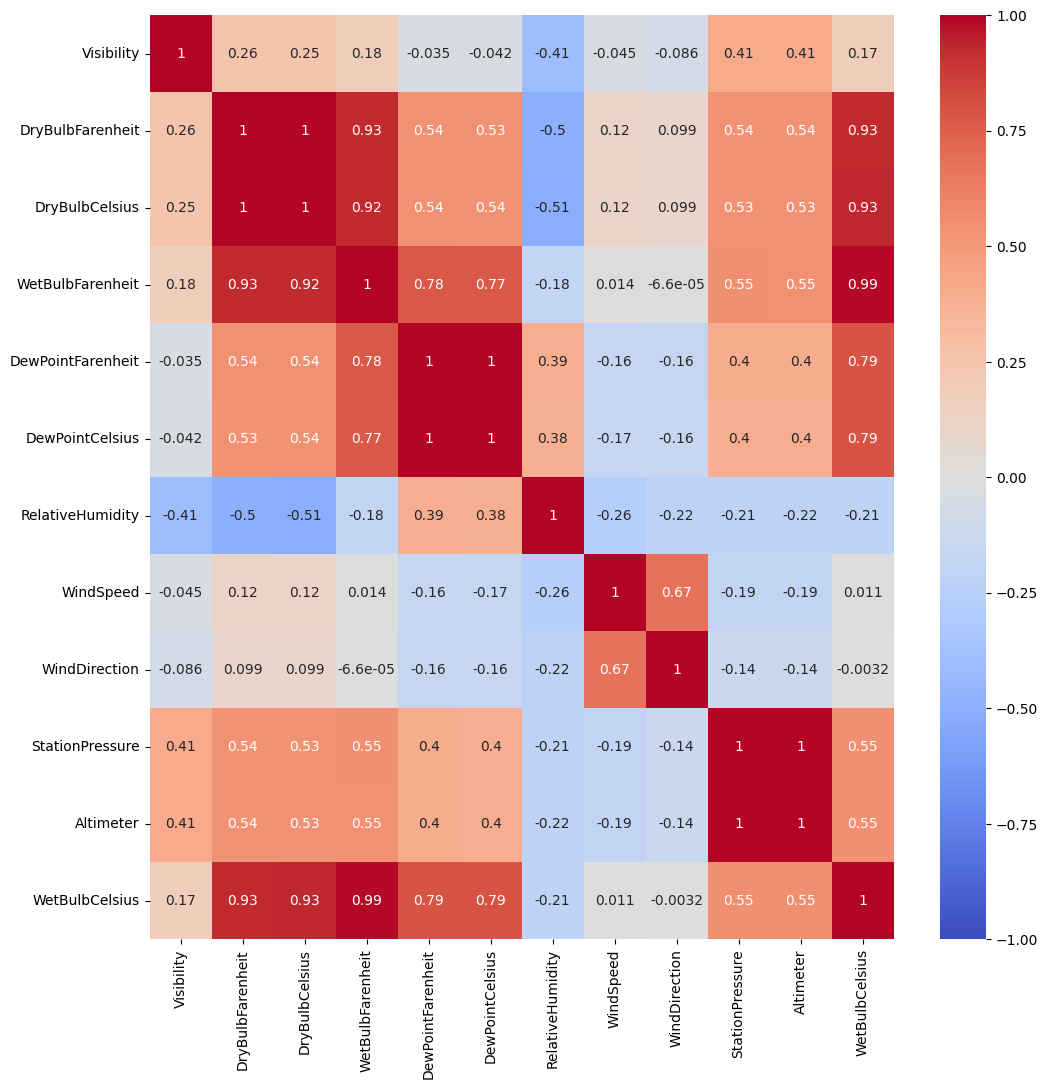

In [130]:
corr = df.corr()
plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

In [131]:
X = df[df.columns[1:6]]
y = df[df.columns[-1:]]

<Axes: >

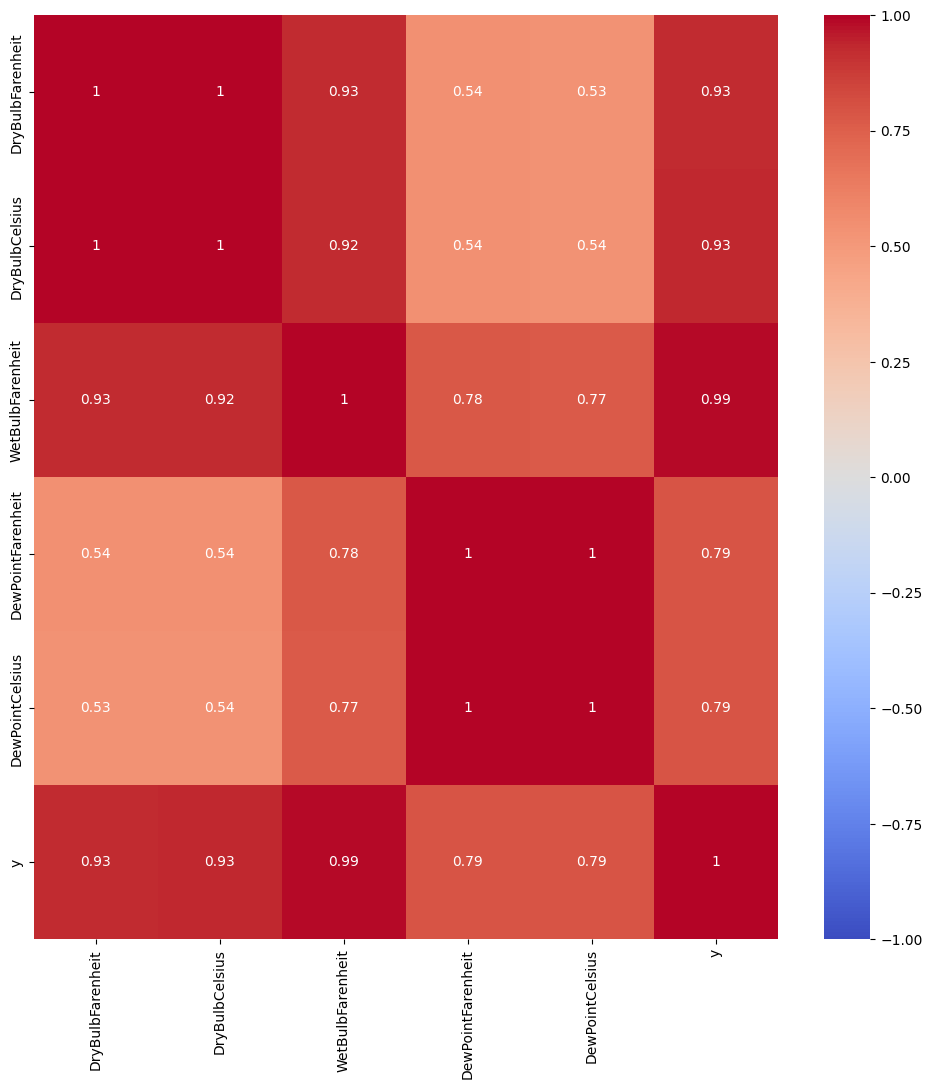

In [132]:
aux = X.copy()
aux['y'] = y
corr = aux.corr()
plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

In [133]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
DryBulbFarenheit,35064.0,0.574054,0.168998,0.0,0.445545,0.574257,0.693069,1.0
DryBulbCelsius,35064.0,0.573661,0.168229,0.0,0.446429,0.571429,0.696429,1.0
WetBulbFarenheit,35064.0,0.645688,0.164795,0.0,0.532468,0.636364,0.779221,1.0
DewPointFarenheit,35064.0,0.576285,0.164861,0.0,0.465909,0.545455,0.693182,1.0
DewPointCelsius,35064.0,0.578015,0.164028,0.0,0.469388,0.551020,0.693878,1.0


In [134]:
# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

In [135]:
X_train = torch.tensor(X_train.values, dtype=torch.float32).to(device)
X_val = torch.tensor(X_val.values, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test.values, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train.values, dtype=torch.float32).to(device)
y_val = torch.tensor(y_val.values, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test.values, dtype=torch.float32).to(device)

In [136]:
# Agregar una dimensión adicional para los timesteps (necesario para GRU)
X_train = X_train.unsqueeze(1)  # Añadir dimensión para "timesteps"
X_val = X_val.unsqueeze(1)
X_test = X_test.unsqueeze(1)

In [137]:
input_size = len(X_scaled.columns)  # Número de variables de entrada
hidden_size = 50  # Número de unidades en la GRU
output_size = len(y.columns)  # Predicción de una variable
num_layers = 1  # Una sola capa GRU

# Crear el modelo
model = GRUModel(input_size, hidden_size, output_size, num_layers).to(device)

# Definir la función de pérdida y el optimizador
criterion = nn.MSELoss()  # Error cuadrático medio
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [138]:
train_dataloader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=False)
val_dataloader = DataLoader(TensorDataset(X_val, y_val), batch_size=64, shuffle=False)
test_dataloader = DataLoader(TensorDataset(X_test, y_test), batch_size=64, shuffle=False)

In [139]:
# Load checkpoint
# Comment if you want to train the model
model.load_state_dict(torch.load(os.path.join(CHECKPOINT_PATH, 'WTH','gru.pth')))

<All keys matched successfully>

In [140]:
trainer = Trainer(
    model = model,
    train_generator = train_dataloader,
    val_generator = val_dataloader,
    device = device,
    criterion = criterion,
    optimizer = optimizer,
    epoch_scheduler = None,
    batch_scheduler = None,
    patience = 10,
    epochs = 100,
    checkpoints_path = os.path.join(CHECKPOINT_PATH, 'WTH', 'gru'),
)

In [141]:
# Train the model
# Comment if you want to load the model
# trainer.fit(verbose=True)

In [142]:
predictions = trainer.eval_dataloader(test_dataloader)

/mnt/homeGPU/JJavierAR/repsol_env/lib/python3.11/site-packages/torch/nn/modules/rnn.py:1102: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /opt/conda/conda-bld/pytorch_1699449183005/work/aten/src/ATen/native/cudnn/RNN.cpp:982.)
  result = _VF.gru(input, hx, self._flat_weights, self.bias, self.num_layers,


In [143]:
predictions = torch.cat(predictions, dim=0)
predictions.shape

torch.Size([7013, 1])

In [144]:
predictions = predictions.cpu().detach().numpy()
y_test = y_test.cpu().detach().numpy()

In [145]:
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

In [146]:
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R2: {r2:.2f}')

MSE: 0.04
RMSE: 0.20
MAE: 0.10
R2: 1.00
